<a href="https://colab.research.google.com/github/tixomirof/mo2_team_colabs/blob/main/%D0%9C%D0%9E2_%D0%9A%D0%BE%D0%BC%D0%B0%D0%BD%D0%B4%D0%B02_%D0%9B%D0%B0%D0%B103_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Упражнения по логистической регрессии

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (accuracy_score,
                             confusion_matrix,
                             classification_report,
                             ConfusionMatrixDisplay,
                             precision_recall_curve,
                             PrecisionRecallDisplay,
                             RocCurveDisplay)

Загрузим датасет, полученный в первой лабораторной работе

In [3]:
df = pd.read_csv('Engineered_Data.csv')
df.head()

,Employment,YearsCode,YearsCodePro,PreviousSalary,ComputerSkills,Employed,APL,ASP.NET,ASP.NET Core,AWS,...,Age_>35,Accessibility_Yes,EdLevel_NoHigherEd,EdLevel_Other,EdLevel_PhD,EdLevel_Undergraduate,Gender_NonBinary,Gender_Woman,MentalHealth_Yes,MainBranch_NotDev
0,1,7.0,4,51552.0,4,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,1,12.0,5,46482.0,12,1,0,0,0,1,...,False,False,False,False,False,True,False,False,False,False
2,1,15.0,6,77290.0,7,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,1,9.0,6,46135.0,13,0,0,0,0,1,...,False,False,False,False,False,True,False,False,False,False
4,0,40.0,30,160932.0,2,0,0,0,0,0,...,True,False,False,False,True,False,False,False,False,True


In [4]:
df['Employed'].unique()

array([0, 1])

Проверим, что в датасете нет пропусков

In [5]:
df.isnull().sum()

,0
Employment,0
YearsCode,0
YearsCodePro,0
PreviousSalary,0
ComputerSkills,0
...,...
EdLevel_Undergraduate,0
Gender_NonBinary,0
Gender_Woman,0
MentalHealth_Yes,0


In [6]:
# Только столбцы, содержащие null значения
df.isnull().sum()[df.isnull().sum() > 0]

,0


Выведем статистический отчёт о числовых колонках

In [7]:
df.describe()

,Employment,YearsCode,YearsCodePro,PreviousSalary,ComputerSkills,Employed,APL,ASP.NET,ASP.NET Core,AWS,...,Unity 3D,Unreal Engine,VBA,VMware,Vue.js,Xamarin,Yarn,jQuery,npm,gdp
count,69686.000000,69686.000000,69686.000000,69686.000000,69686.000000,69686.000000,69686.000000,69686.000000,69686.000000,69686.000000,...,69686.000000,69686.000000,69686.000000,69686.000000,69686.000000,69686.000000,69686.00000,69686.000000,69686.000000,6.968600e+04
mean,0.883119,14.250753,9.059725,68058.053124,13.414416,0.535273,0.002856,0.137976,0.171742,0.429943,...,0.057917,0.019545,0.045475,0.024122,0.159917,0.020391,0.20789,0.255589,0.231496,7.039715e+12
std,0.321281,9.383279,7.932900,49362.776837,7.036527,0.498758,0.053362,0.344877,0.377159,0.495071,...,0.233588,0.138431,0.208346,0.153431,0.366532,0.141336,0.40580,0.436195,0.421791,1.034076e+13
min,0.000000,0.000000,0.000000,200.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,6.540000e+08
25%,1.000000,7.000000,3.000000,29436.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,5.456290e+11
50%,1.000000,12.000000,7.000000,58034.500000,13.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,2.173666e+12
75%,1.000000,20.000000,12.000000,95979.000000,17.000000,1.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,4.456081e+12
max,1.000000,50.000000,50.000000,224000.000000,107.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,2.736094e+13


Выведем количество точек для каждого значения Employed

In [8]:
df['Employed'].value_counts()

,count
Employed,
1,37301
0,32385


<Axes: xlabel='Employed', ylabel='count'>

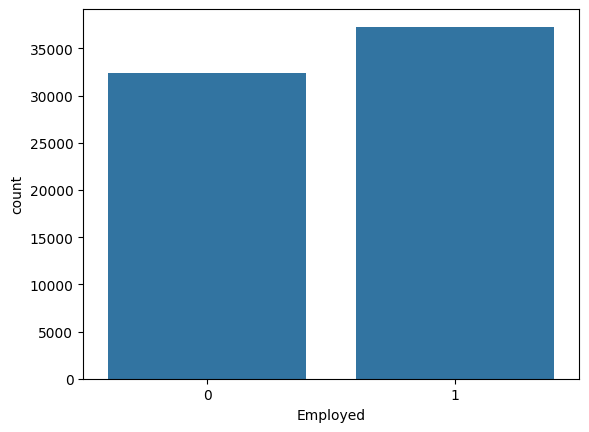

In [9]:
sns.countplot(data=df, x='Employed')

Можно заметить, что классы сбалансированы

Нарисуем график pairplot, показывающий связи между колонками 'YearsCode', 'YearsCodePro', 'PreviousSalary', 'ComputerSkills', 'gdp', 'Employed'

In [10]:
df.columns

Index(['Employment', 'YearsCode', 'YearsCodePro', 'PreviousSalary',
       'ComputerSkills', 'Employed', 'APL', 'ASP.NET', 'ASP.NET Core ', 'AWS',
       ...
       'Age_>35', 'Accessibility_Yes', 'EdLevel_NoHigherEd', 'EdLevel_Other',
       'EdLevel_PhD', 'EdLevel_Undergraduate', 'Gender_NonBinary',
       'Gender_Woman', 'MentalHealth_Yes', 'MainBranch_NotDev'],
      dtype='object', length=133)

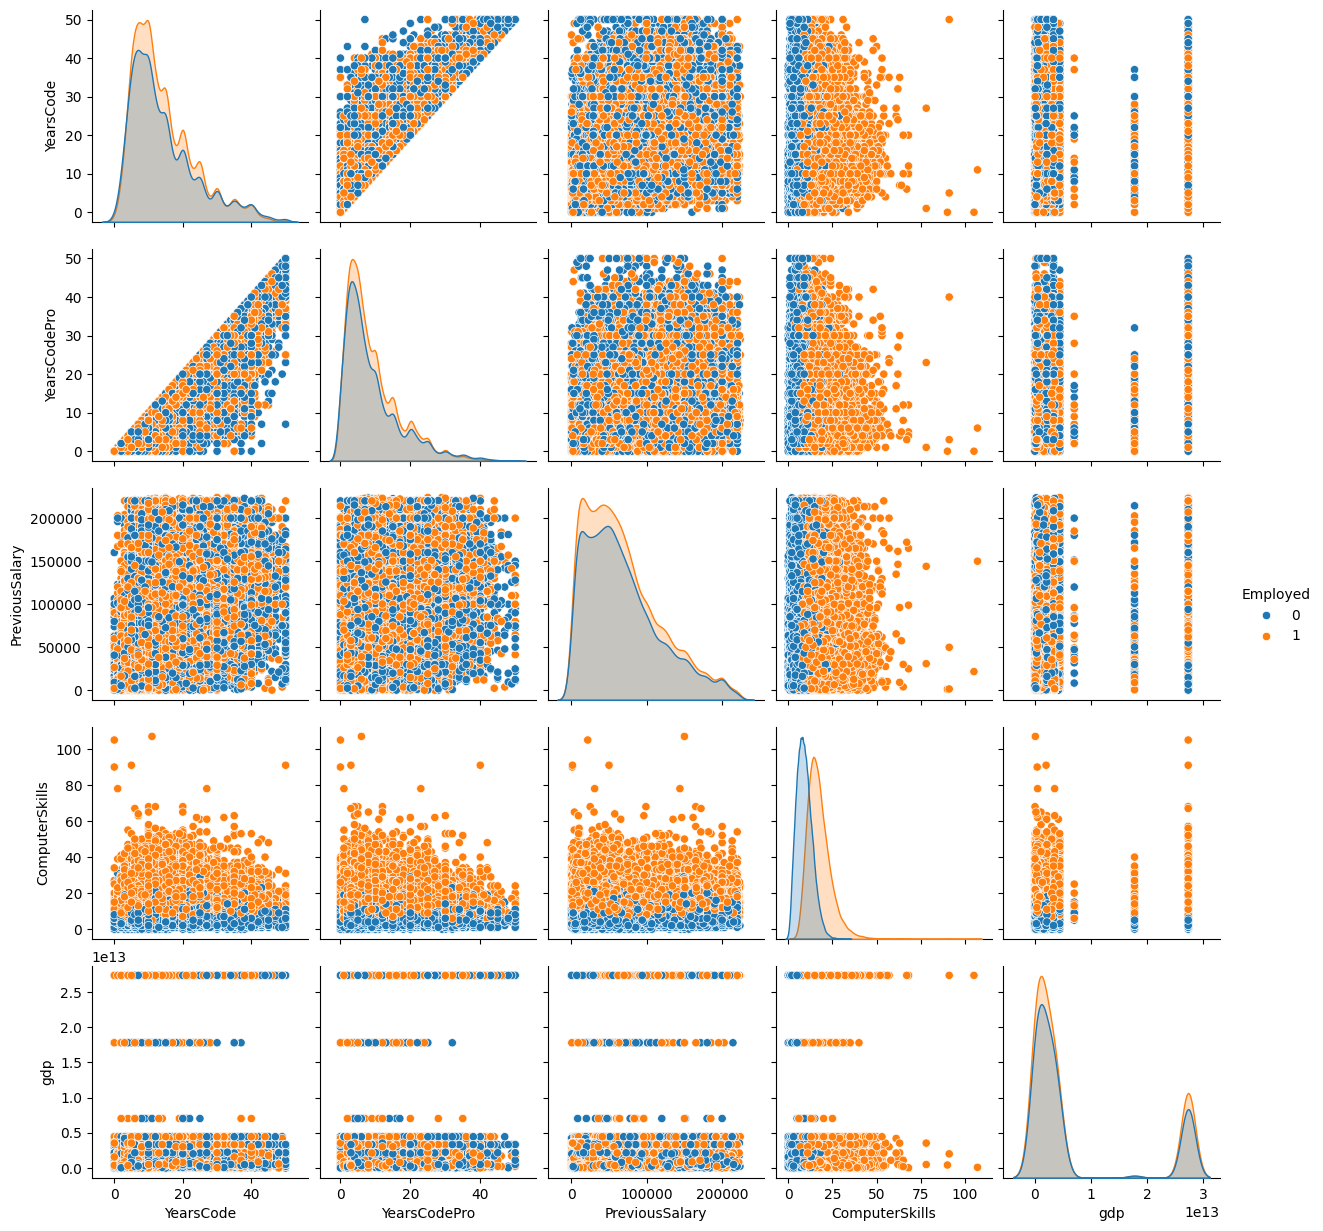

In [14]:
sns.pairplot(df[['YearsCode','YearsCodePro', 'PreviousSalary','ComputerSkills','gdp','Employed']],hue='Employed')

По графикам заметно, что в основном только по ComputerSkills можно разделить данные на два класса Employed

Нарисуем график heatmap, показывающий корреляции между всеми колонками. Поскольку признаков больше сотни, на графике будет тяжело прочитать все. Выведем только топ 15.

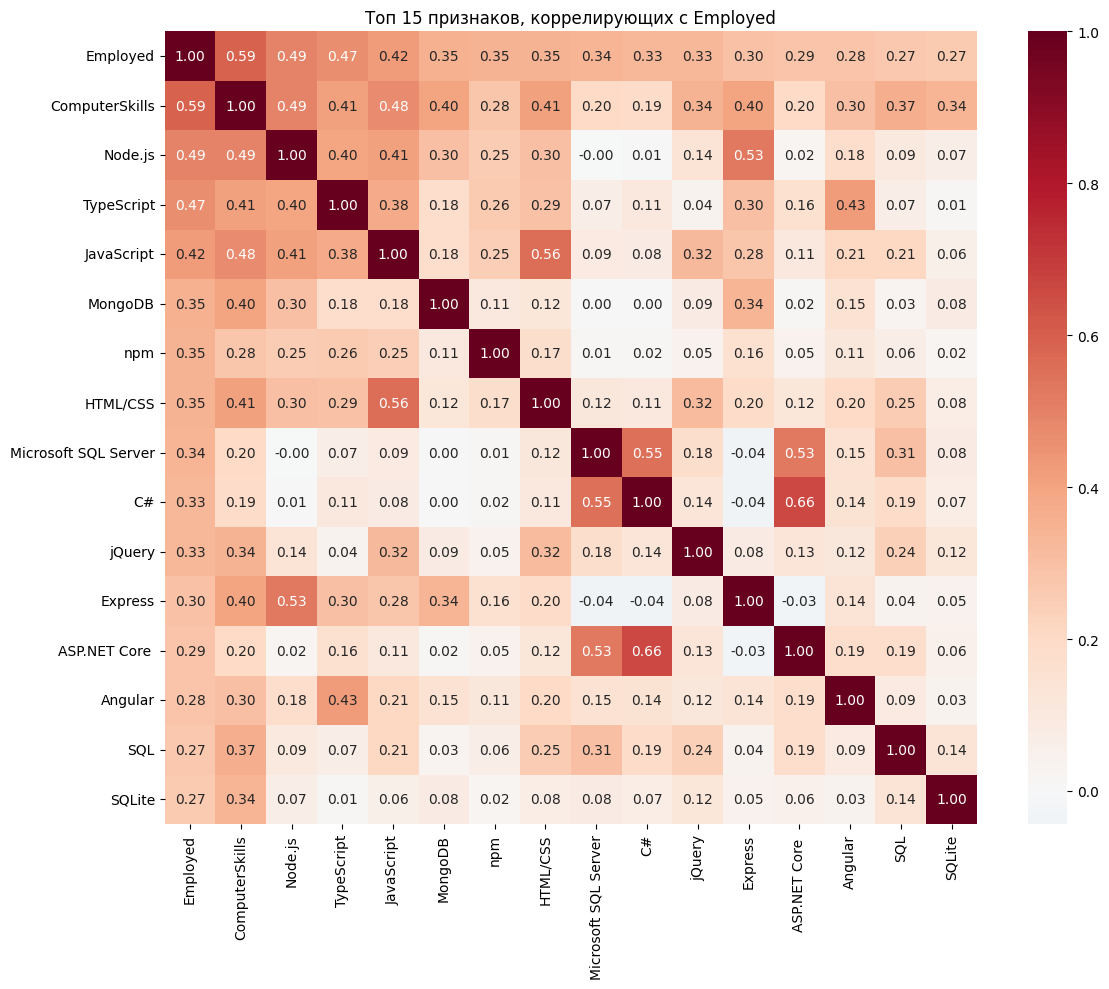

In [11]:
target = 'Employed'
top_n = 15

corr_with_target = df.corr(numeric_only=True)[target].abs().sort_values(ascending=False)
corr_with_target = corr_with_target.drop(target)
top_features = corr_with_target.head(top_n).index.tolist()
top_features_with_target = [target] + top_features

plt.figure(figsize=(12, 10))
sns.heatmap(df[top_features_with_target].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title(f'Топ {top_n} признаков, коррелирующих с {target}')
plt.tight_layout()
plt.show()

На матрице корреляций видно, что с прогнозируемым признаком сильнее всего коррелируют только признаки, выделенные из `ComputerSkills` и сам `ComputerSkills`.

##Разбиение на обучающий и тестовый наборы данных

Разделим все признаки на 2 объекта, X и y

In [30]:
X = df.drop('Employed',axis=1)
y = df['Employed']

Разделим данные на обучающий и тестовый наборы данных. Для тестовых данных используем размер 10%

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

##Модель логистической регрессии

In [34]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegressionCV(
        Cs=20,
        cv=5,
        penalty='l2',
        solver='lbfgs',
        scoring='roc_auc',
        max_iter=2000
    ))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegressionCV(Cs=20, cv=5, max_iter=2000,
                                      scoring='roc_auc'))])

 Отобразим результаты поиска оптимальных параметров, особенно значение C.

In [35]:
print("Test accuracy:", pipeline.score(X_test, y_test))

Test accuracy: 1.0


In [36]:
print("Лучший C:", pipeline.named_steps["clf"].C_)

Лучший C: [0.00483293]


In [37]:
pipeline.named_steps["clf"].get_params()

{'Cs': 20,
 'class_weight': None,
 'cv': 5,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1.0,
 'l1_ratios': None,
 'max_iter': 2000,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'refit': True,
 'scoring': 'roc_auc',
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0}

Отобразим коэффициенты модели

In [38]:
model = pipeline.named_steps["clf"]
print(model.coef_)

[[-1.10673502e-02  5.13824653e-02 -2.32486001e-02  3.79792562e-05
   1.00199151e+00 -1.52786817e-02  8.09577406e-02  1.08538088e-01
  -7.10824322e-02  7.15354465e-02 -4.10945327e-03 -2.66326980e-02
  -1.20376568e-02  1.66670396e+00 -2.90997349e-02 -2.45875051e-02
   1.58688204e+00 -9.91425130e-03 -1.43812191e-02 -2.23399823e-02
  -2.00663317e-02 -2.50841914e-02 -2.15564110e-02 -1.48528008e-02
  -9.59023008e-03 -1.55047548e-02 -1.23094629e-02 -1.25985165e-02
  -2.45162544e-02  1.03954178e-03 -3.46599657e-02 -6.06567695e-02
  -3.68645474e-02 -1.66637241e-02 -1.09149542e-02 -4.43330843e-02
  -2.04366649e-02 -2.11274832e-02  5.47091814e-02  7.36749966e-04
  -3.90051363e-02  3.25699132e-03 -1.30017077e-02 -1.92827367e-03
  -3.04600716e-02 -1.77862371e-02 -6.71173025e-03 -2.95433631e-02
  -1.19841946e-01 -3.15786189e-02 -4.48667864e-02 -5.49144496e-02
   3.72784171e-03 -3.38661833e-03 -1.62037628e-02 -4.46589739e-02
  -5.50735702e-03 -9.94528562e-03  8.94889816e-04  1.65564222e+00
   6.69798

 Сделаем визуализацию коэффициентов, нарисуя их с помощью графика barplot

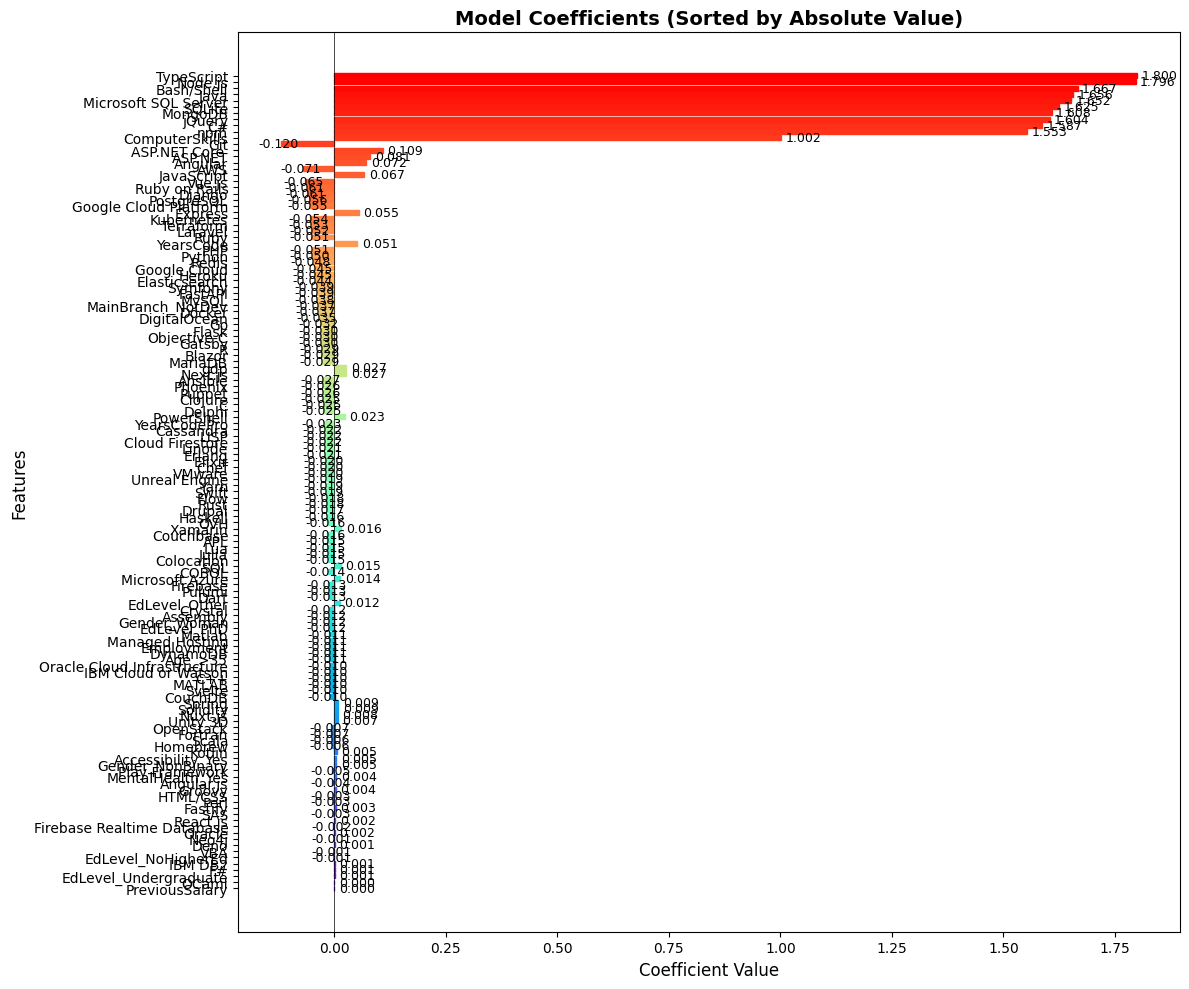


Топ-5 признаков с положительным влиянием:
Microsoft SQL Server: 1.6517
Java: 1.6556
Bash/Shell: 1.6667
Node.js: 1.7963
TypeScript: 1.8000

Топ-5 признаков с отрицательным влиянием:
EdLevel_NoHigherEd: -0.0009
VBA: -0.0010
Neo4j: -0.0014
Firebase Realtime Database: -0.0019
SAS: -0.0031


In [19]:
coefficients = model.coef_[0]
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': coefficients
})

# сортировка
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=True).index)

plt.figure(figsize=(12, 10))
bars = plt.barh(coef_df['feature'], coef_df['coefficient'])

colors = plt.cm.rainbow(np.linspace(0, 1, len(coef_df)))
for i, (bar, color) in enumerate(zip(bars, colors)):
    bar.set_color(color)

plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Model Coefficients (Sorted by Absolute Value)', fontsize=14, fontweight='bold')

for i, (feature, coef) in enumerate(zip(coef_df['feature'], coef_df['coefficient'])):
    plt.text(coef + (0.01 if coef >= 0 else -0.05), i,
             f'{coef:.3f}',
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nТоп-5 признаков с положительным влиянием:")
top_positive = coef_df[coef_df['coefficient'] > 0].tail(5)
for idx, row in top_positive.iterrows():
    print(f"{row['feature']}: {row['coefficient']:.4f}")

print("\nТоп-5 признаков с отрицательным влиянием:")
top_negative = coef_df[coef_df['coefficient'] < 0].head(5)
for idx, row in top_negative.iterrows():
    print(f"{row['feature']}: {row['coefficient']:.4f}")

##Оценка модели

Оценим работу модели на оставшихся 10% данных - тестовом наборе данных

In [39]:
y_pred = pipeline.predict(X_test)

In [40]:
accuracy_score(y_test,y_pred)

1.0

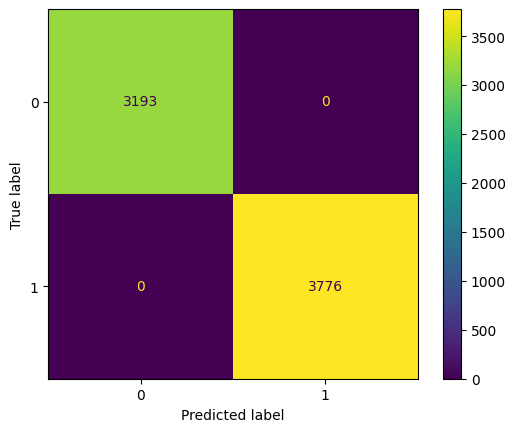

In [41]:
ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test)

In [42]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3193
           1       1.00      1.00      1.00      3776

    accuracy                           1.00      6969
   macro avg       1.00      1.00      1.00      6969
weighted avg       1.00      1.00      1.00      6969



Результаты... весьма занимательные, точность модели достигает 100% при заданных параметрах. Она падает если пытаться менять параметры (например Cs с 20 до 1 - Accuracy падает до 98%). Если использовать .csv файл до обработки данных, точность модели составляла 80% при тех же параметрах.

##Кривые производительности

Нарисуем графики "precision recall curve" и "ROC Curve"

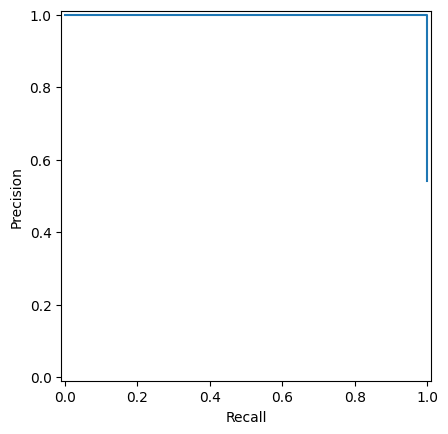

In [47]:
precision, recall, _ = precision_recall_curve(y_test, y_pred)
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()
plt.show()

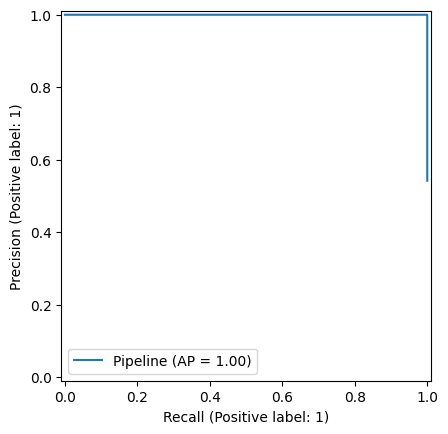

In [48]:
PrecisionRecallDisplay.from_estimator(pipeline, X_test, y_test)

Очевидно, эти графики полностью держатся на единице, поскольку модель в абсолютной точности предсказывает всё.